# Import the Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import normal_ad

In [2]:
df = pd.read_csv('CompanyABCProfit.csv')

In [3]:
df.head()

,Year,Profit(Rs '000)
0,1821,1645
1,1822,658
2,1823,1926
3,1824,865
4,1825,764


In [10]:
# Select Profit column
profit = df["Profit(Rs '000)"].dropna()

In [23]:
profit[profit<0]

,Profit(Rs '000)
105,-244
167,-413
197,-178


# PDF Plot

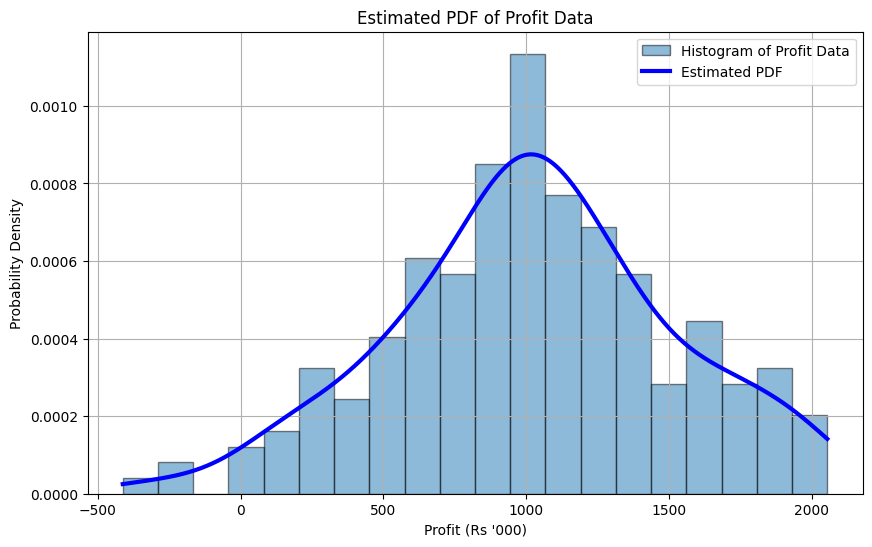

In [11]:
# ---------------------------------------------------------
# Estimate PDF using KDE
# ---------------------------------------------------------
kde = stats.gaussian_kde(profit)

# Create x values
x = np.linspace(profit.min(), profit.max(), 1000)

# Estimated PDF values
estimated_pdf = kde(x)

# ---------------------------------------------------------
# Plot Histogram + Estimated PDF
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Histogram as density
plt.hist(
    profit,
    bins=20,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Histogram of Profit Data"
)

# Estimated PDF in blue
plt.plot(
    x,
    estimated_pdf,
    color="blue",
    linewidth=3,
    label="Estimated PDF"
)

plt.title("Estimated PDF of Profit Data")
plt.xlabel("Profit (Rs '000)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

# Fitted Normal Distribution

Fitted Normal Distribution
--------------------------
Mean = 1021.9900
Standard Deviation = 486.7342

Goodness of Fit
----------------
Least Squares Error = 0.0000002428
Mean Squared Error  = 0.0000000121


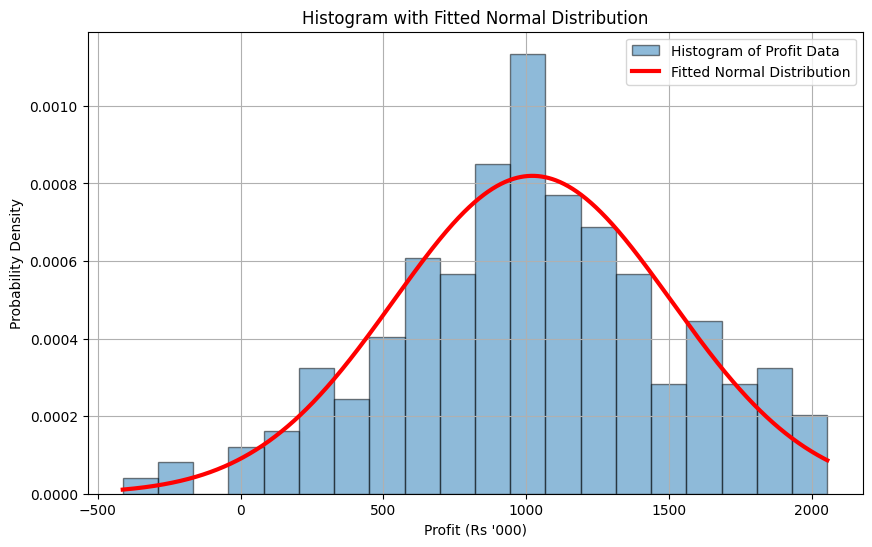

In [12]:
# ---------------------------------------------------------
# Fit Normal Distribution
# ---------------------------------------------------------
mu, sigma = stats.norm.fit(profit)

print("Fitted Normal Distribution")
print("--------------------------")
print(f"Mean = {mu:.4f}")
print(f"Standard Deviation = {sigma:.4f}")

# ---------------------------------------------------------
# Create histogram density values
# ---------------------------------------------------------
counts, bin_edges = np.histogram(
    profit,
    bins=20,
    density=True
)

# Find center point of each histogram bin
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Get fitted normal PDF values at bin centers
fitted_pdf_at_bins = stats.norm.pdf(bin_centers, mu, sigma)

# ---------------------------------------------------------
# Goodness of Fit using Least Squares and MSE
# ---------------------------------------------------------
errors = counts - fitted_pdf_at_bins

least_square_error = np.sum(errors ** 2)
mse = np.mean(errors ** 2)

print()
print("Goodness of Fit")
print("----------------")
print(f"Least Squares Error = {least_square_error:.10f}")
print(f"Mean Squared Error  = {mse:.10f}")

# ---------------------------------------------------------
# Create smooth fitted normal curve
# ---------------------------------------------------------
x = np.linspace(profit.min(), profit.max(), 1000)
normal_pdf = stats.norm.pdf(x, mu, sigma)

# ---------------------------------------------------------
# Plot Histogram + Fitted Normal Curve
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Histogram
plt.hist(
    profit,
    bins=20,
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Histogram of Profit Data"
)

# Fitted normal curve
plt.plot(
    x,
    normal_pdf,
    color="red",
    linewidth=3,
    label="Fitted Normal Distribution"
)

plt.title("Histogram with Fitted Normal Distribution")
plt.xlabel("Profit (Rs '000)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

# Normality Test Summary Table

In [17]:
# ---------------------------------------------------------
# 1. Kolmogorov-Smirnov Test
# ---------------------------------------------------------
# Fit mean and standard deviation from the data
mean = profit.mean()
std = profit.std(ddof=1)

ks_stat, ks_p = stats.kstest(profit, 'norm', args=(mean, std))

# ---------------------------------------------------------
# 2. Shapiro-Wilk Test
# ---------------------------------------------------------
shapiro_stat, shapiro_p = stats.shapiro(profit)

# ---------------------------------------------------------
# 3. Anderson-Darling Test
# ---------------------------------------------------------
# This statsmodels version gives p-value directly
ad_stat, ad_p = normal_ad(profit)

# ---------------------------------------------------------
# Print Results
# ---------------------------------------------------------
print("Normality Test Results for Profit Column")
print("----------------------------------------")

print(f"Kolmogorov-Smirnov Test:")
print(f"Statistic = {ks_stat:.4f}")
print(f"p-value   = {ks_p:.4f}")

print()

print(f"Shapiro-Wilk Test:")
print(f"Statistic = {shapiro_stat:.4f}")
print(f"p-value   = {shapiro_p:.4f}")

print()

print(f"Anderson-Darling Test:")
print(f"Statistic = {ad_stat:.4f}")
print(f"p-value   = {ad_p:.4f}")

print()

# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------
alpha = 0.05

print("Interpretation:")
print("---------------")

if ks_p > alpha:
    print("Kolmogorov-Smirnov: Fail to reject H0 → Profit is approximately normal")
else:
    print("Kolmogorov-Smirnov: Reject H0 → Profit is not normally distributed")

if shapiro_p > alpha:
    print("Shapiro-Wilk: Fail to reject H0 → Profit is approximately normal")
else:
    print("Shapiro-Wilk: Reject H0 → Profit is not normally distributed")

if ad_p > alpha:
    print("Anderson-Darling: Fail to reject H0 → Profit is approximately normal")
else:
    print("Anderson-Darling: Reject H0 → Profit is not normally distributed")

Normality Test Results for Profit Column
----------------------------------------
Kolmogorov-Smirnov Test:
Statistic = 0.0403
p-value   = 0.8878

Shapiro-Wilk Test:
Statistic = 0.9906
p-value   = 0.2167

Anderson-Darling Test:
Statistic = 0.4585
p-value   = 0.2608

Interpretation:
---------------
Kolmogorov-Smirnov: Fail to reject H0 → Profit is approximately normal
Shapiro-Wilk: Fail to reject H0 → Profit is approximately normal
Anderson-Darling: Fail to reject H0 → Profit is approximately normal


# Q–Q Plot

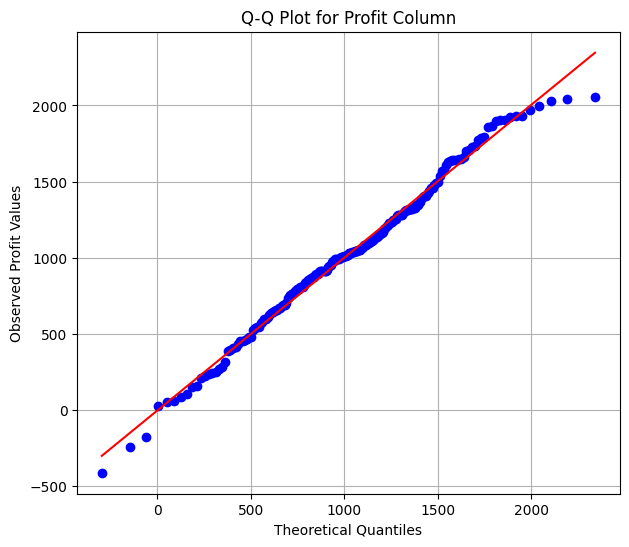

In [14]:
# Fit normal distribution parameters
mean = profit.mean()
std = profit.std(ddof=1)

# Create Q-Q plot
plt.figure(figsize=(7, 6))

stats.probplot(profit, dist="norm", sparams=(mean, std), plot=plt)

plt.title("Q-Q Plot for Profit Column")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Profit Values")

plt.grid(True)
plt.show()

Profit Column Summary
---------------------
Mean = 1021.99
Standard Deviation = 487.96


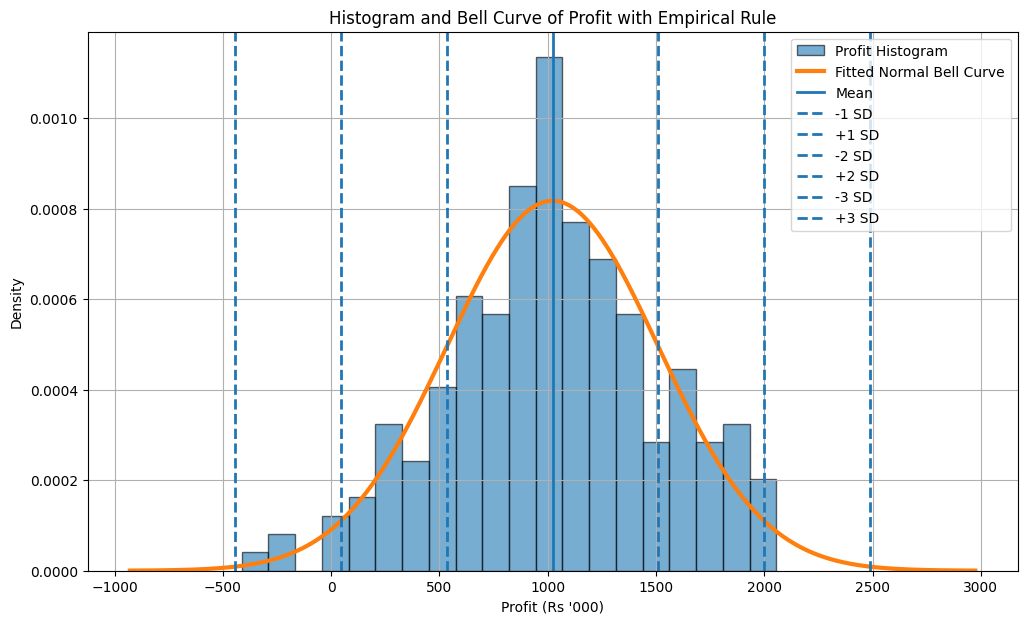

In [15]:
# ---------------------------------------------------------
# Calculate mean and standard deviation
# ---------------------------------------------------------
mean = profit.mean()
std = profit.std(ddof=1)

print("Profit Column Summary")
print("---------------------")
print(f"Mean = {mean:.2f}")
print(f"Standard Deviation = {std:.2f}")

# ---------------------------------------------------------
# Create values for normal bell curve
# ---------------------------------------------------------
x = np.linspace(mean - 4*std, mean + 4*std, 1000)
normal_curve = stats.norm.pdf(x, mean, std)

# ---------------------------------------------------------
# Plot Histogram + Bell Curve
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

# Histogram
plt.hist(
    profit,
    bins=20,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Profit Histogram"
)

# Bell curve
plt.plot(
    x,
    normal_curve,
    linewidth=3,
    label="Fitted Normal Bell Curve"
)

# Mean line
plt.axvline(mean, linestyle="-", linewidth=2, label="Mean")

# Empirical rule lines
plt.axvline(mean - std, linestyle="--", linewidth=2, label="-1 SD")
plt.axvline(mean + std, linestyle="--", linewidth=2, label="+1 SD")

plt.axvline(mean - 2*std, linestyle="--", linewidth=2, label="-2 SD")
plt.axvline(mean + 2*std, linestyle="--", linewidth=2, label="+2 SD")

plt.axvline(mean - 3*std, linestyle="--", linewidth=2, label="-3 SD")
plt.axvline(mean + 3*std, linestyle="--", linewidth=2, label="+3 SD")

# Titles and labels
plt.title("Histogram and Bell Curve of Profit with Empirical Rule")
plt.xlabel("Profit (Rs '000)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()